<a href="https://colab.research.google.com/github/August0-mp/music-genre-classifier/blob/main/music_genre_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Music Genre Classification

Classifying short music clips into one of **10 genres** using the classic
[GTZAN dataset](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification).

This notebook walks through the full machine-learning pipeline end to end:

1. **Setup** – import the scientific-Python / audio / ML stack.
2. **The dataset** – download GTZAN and understand what it contains.
3. **Understanding audio** – waveforms, spectrograms and MFCCs, the features that make
   audio "learnable".
4. **Tabular features** – use the pre-computed feature tables shipped with the dataset.
5. **Pre-processing** – encode labels, split train/test, standardize features.
6. **Classical models** – train and evaluate Logistic Regression, SVM, Decision Tree
   and Random Forest.
7. **Going further** – compare all models, exploit the 3-second segments, tune
   hyper-parameters, and train a small neural network in PyTorch.
8. **Conclusion** – what worked, the pitfalls, and where to go next.

> **The GTZAN dataset** contains 1 000 audio tracks (each 30 s long), 100 per genre:
> *blues, classical, country, disco, hip-hop, jazz, metal, pop, reggae* and *rock*.
> Alongside the raw `.wav` files it ships two CSVs of hand-engineered features
> (computed over the full 30 s clips and over 3 s segments) which let us train
> classical models without doing the signal processing ourselves.


## 1. Libraries & setup

We rely on three families of tools:

| Purpose | Libraries |
|---|---|
| Numerical / data | `numpy`, `pandas`, `matplotlib` |
| Audio processing  | `librosa`, `torchaudio`, `IPython.display` (to play clips) |
| Machine learning  | `scikit-learn` (classical models), `torch` (neural net) |

We also seed the random number generators so the results below are reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sklearn as skt
# Explicitly pull in the scikit-learn sub-modules we use, so that `skt.<module>`
# is always available regardless of import side effects.
from sklearn import (
    preprocessing,
    model_selection,
    linear_model,
    svm,
    tree,
    ensemble,
    neighbors,
    metrics,
)

import torch
import torch.nn as nn
import torchaudio

import librosa
import librosa.display
import IPython.display as ipd

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 100


## 2. The GTZAN dataset

### 2.1 Downloading the data

[`kagglehub`](https://github.com/Kaggle/kagglehub) downloads (and caches) the dataset
straight from Kaggle and returns the local path to the files. The first run downloads
~1.2 GB; subsequent runs reuse the cached copy.


In [2]:
import kagglehub

path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

100%|██████████| 1.21G/1.21G [01:15<00:00, 17.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1


## 3. Understanding audio: waveforms, spectrograms & MFCCs

A raw audio signal is just a long 1-D array of amplitude values sampled thousands of
times per second (the *sample rate*). That representation is hard for a model to learn
from directly, so we transform it into the **time–frequency** domain.

- **Spectrogram (STFT).** The Short-Time Fourier Transform slices the signal into short
  overlapping windows and computes, for each, how much energy lives at every frequency.
  The result is an image: time on the x-axis, frequency on the y-axis, energy as colour.
  We plot it on both a **linear** and a **log** frequency axis (human hearing is roughly
  logarithmic, so the log view is more perceptually meaningful).
- **MFCCs (Mel-Frequency Cepstral Coefficients).** A compact summary (typically ~13–20
  numbers per frame) that captures the *timbre* / spectral shape of the sound on the
  perceptually-motivated **mel** scale. MFCCs are the workhorse feature of audio ML and
  are what most of the columns in the feature CSVs are built from.

### 3.1 Helper – power spectrogram


In [3]:
def plot_spectogram(data, sample_rate):
    data_stft = librosa.stft(data)
    data_stft_db = librosa.amplitude_to_db(np.abs(data_stft), ref=np.max)

    fig, ax = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=(10, 8),
        constrained_layout=True
    )

    img1 = librosa.display.specshow(
        data_stft_db,
        y_axis='linear',
        x_axis='time',
        sr=sample_rate,
        ax=ax[0]
    )
    ax[0].set_title('Linear-frequency power spectrogram')

    img2 = librosa.display.specshow(
        data_stft_db,
        y_axis='log',
        x_axis='time',
        sr=sample_rate,
        ax=ax[1]
    )
    ax[1].set_title('Log-frequency power spectrogram')

    fig.colorbar(
        img2,
        ax=ax,
        format='%+2.0f dB'
    )

    plt.show()

### 3.2 Helper – MFCCs

In [4]:
def plot_MFCCs(data, sample_rate):
    data_mfccs = librosa.feature.mfcc(y=data, sr=sample_rate)

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(10, 8),
        constrained_layout=True
    )

    img = librosa.display.specshow(
        data_mfccs,
        x_axis='time',
        ax=ax
    )

    ax.set_title('MFCCs')
    plt.colorbar(img, ax=ax, format='%0.2f')

    plt.show()

### 3.3 Load one example clip

`librosa.load` reads a `.wav` file into a NumPy array and (by default) resamples it to
22 050 Hz and mixes it down to mono. We grab the first blues track as our example.


In [5]:
data, sample_rate = librosa.load(path+"/Data/genres_original/blues/blues.00000.wav")

Let's listen to it 🎧

In [6]:
ipd.Audio(path+"/Data/genres_original/blues/blues.00000.wav")

### 3.4 Visualising the example

Below are the MFCCs and the spectrograms for this single blues clip. Notice how the
energy is concentrated in the lower frequencies and how rhythmic structure shows up as
vertical striations in time.


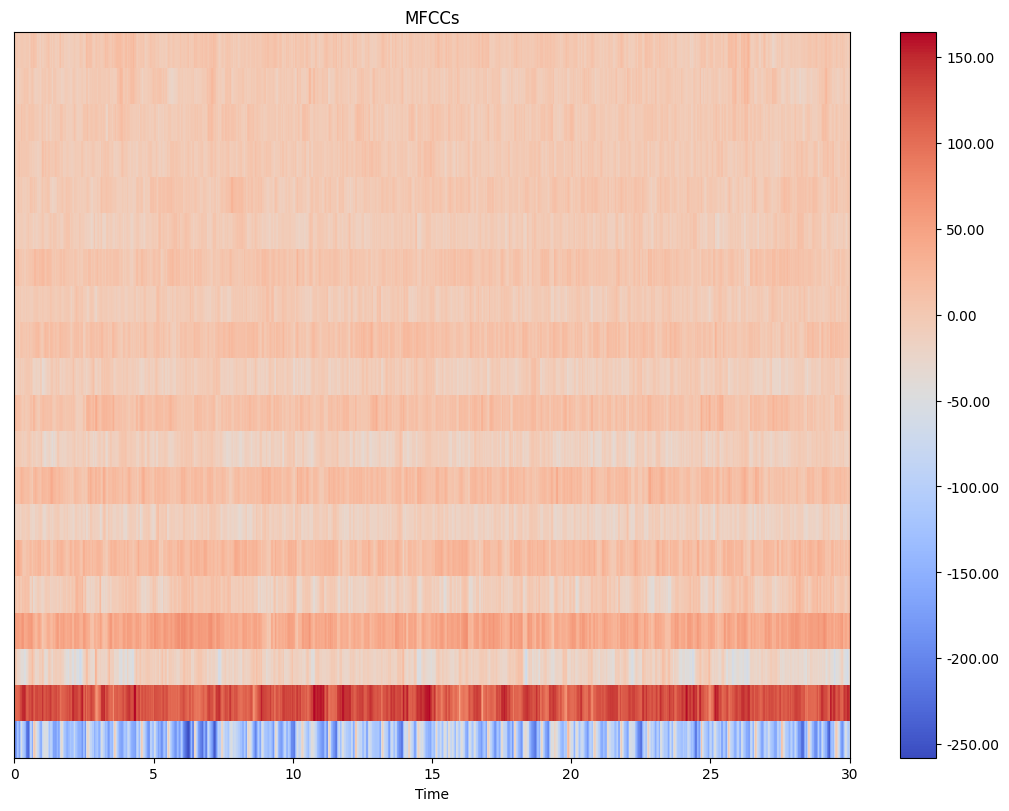

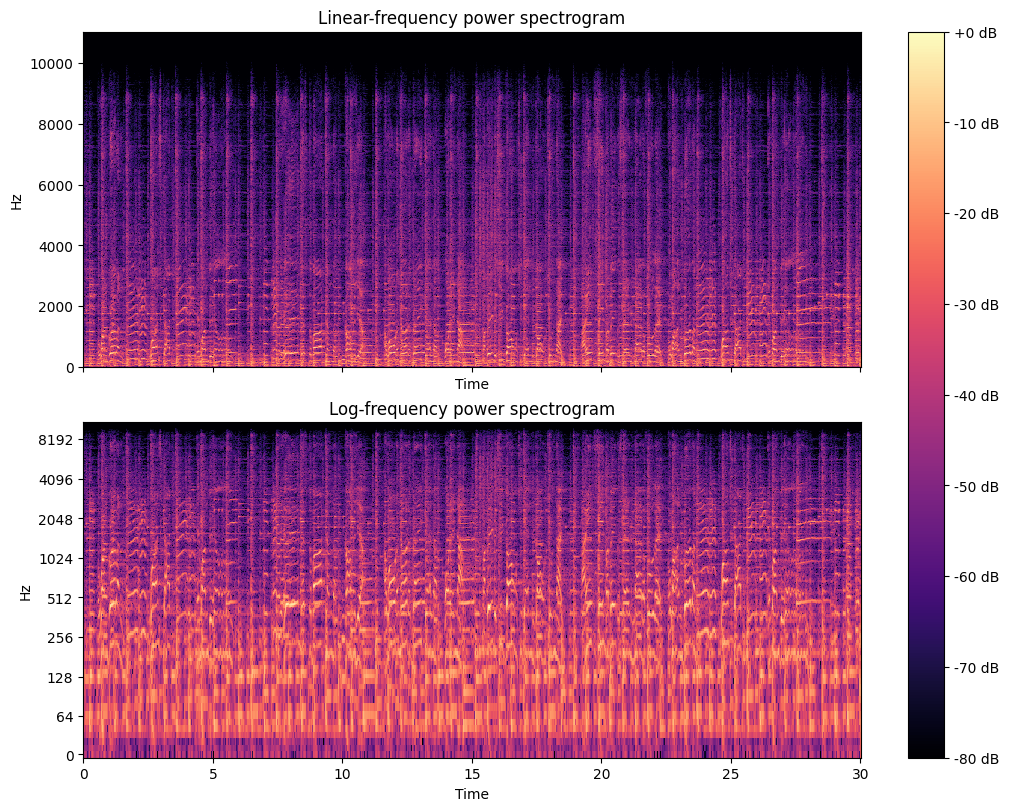

In [7]:
plot_MFCCs(data, sample_rate)
plot_spectogram(data, sample_rate)

## 4. Pre-extracted tabular features

Doing the STFT/MFCC extraction for every file ourselves would be slow. Conveniently,
GTZAN ships two CSVs where this work is already done:

- **`features_30_sec.csv`** – one row per 30 s track → **1 000 rows**.
- **`features_3_sec.csv`** – each track split into ten 3 s segments → **9 990 rows**
  (≈10× more training data).

Each row contains summary statistics (mean & variance) of features such as the
*chroma*, *RMS energy*, *spectral centroid / bandwidth / roll-off*, *zero-crossing
rate*, *tempo*, and the 20 *MFCCs* — roughly 60 numeric columns plus the `filename`,
`length` and `label` columns.

### 4.1 Listing the dataset contents


In [8]:
import os

# `path` was returned by kagglehub above and points at the dataset root.
data_dir = os.path.join(path, "Data")
print("Contents of", data_dir)
for entry in sorted(os.listdir(data_dir)):
    print("  -", entry)


Contents of /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data
  - features_30_sec.csv
  - features_3_sec.csv
  - genres_original
  - images_original


### 4.2 Loading the feature tables

We load both CSVs and preview the 30-second table.


In [9]:
df_30sec = pd.read_csv(path+"/Data/features_30_sec.csv")
df_3sec = pd.read_csv(path+"/Data/features_3_sec.csv")
df_30sec.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


A quick look at the shape and class balance:

In [10]:
print("30 s table :", df_30sec.shape)
print("3 s table  :", df_3sec.shape)
print("\nFeature columns (excluding filename / length / label):",
      df_30sec.shape[1] - 3)
print("\nSamples per genre (30 s table):")
print(df_30sec["label"].value_counts())


30 s table : (1000, 60)
3 s table  : (9990, 60)

Feature columns (excluding filename / length / label): 57

Samples per genre (30 s table):
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


## 5. Pre-processing

Three standard steps before training:

1. **Encode the labels.** Models need integers, not strings, so `LabelEncoder` maps
   each genre name to an integer `0…9`. We keep the encoder (`le`) around so we can map
   predictions back to readable genre names.
2. **Train/test split.** We hold out 20 % of the data to estimate generalisation.
   `random_state` makes the split reproducible.
3. **Standardize the features.** Features live on very different scales (e.g. tempo in
   the hundreds vs. a chroma value in `[0, 1]`). `StandardScaler` rescales each feature
   to zero mean / unit variance. **Important:** the scaler is *fit on the training set
   only* and then applied to the test set, to avoid leaking test-set information.


In [11]:
y = df_30sec["label"]
le = skt.preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y)

# Drop the non-feature columns; everything else is a numeric feature.
X = df_30sec.drop(["filename", "length", "label"], axis=1)

X_train, X_test, y_train, y_test = skt.model_selection.train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Classes:", list(le.classes_))


Train: (800, 57)  Test: (200, 57)
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [12]:
scaler = skt.preprocessing.StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)        # apply to test


## 6. Training & evaluating classical models

### 6.1 Evaluation helper

`evaluate_model` fits a classifier, prints the **accuracy** and a per-genre
**classification report** (precision / recall / F1), and draws a **confusion matrix** so
we can see *which* genres get confused with each other. It returns the accuracy so we can
collect results later.


In [13]:
def evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, le,
                   title=None):
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    acc = skt.metrics.accuracy_score(y_test, pred)
    print("Accuracy:", round(acc, 4))
    print(skt.metrics.classification_report(y_test, pred,
                                            target_names=le.classes_))

    disp = skt.metrics.ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=le.classes_, xticks_rotation=45
    )
    if title:
        disp.ax_.set_title(title)
    plt.show()

    return acc


### 6.2 Logistic Regression

A linear baseline. Despite its simplicity it is a strong baseline on well-engineered
tabular features. `max_iter` is raised so the solver fully converges.


Accuracy: 0.71
              precision    recall  f1-score   support

       blues       0.68      0.65      0.67        20
   classical       0.95      0.95      0.95        20
     country       0.64      0.70      0.67        20
       disco       0.77      0.50      0.61        20
      hiphop       0.60      0.60      0.60        20
        jazz       0.71      0.85      0.77        20
       metal       0.94      0.80      0.86        20
         pop       0.84      0.80      0.82        20
      reggae       0.52      0.70      0.60        20
        rock       0.58      0.55      0.56        20

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



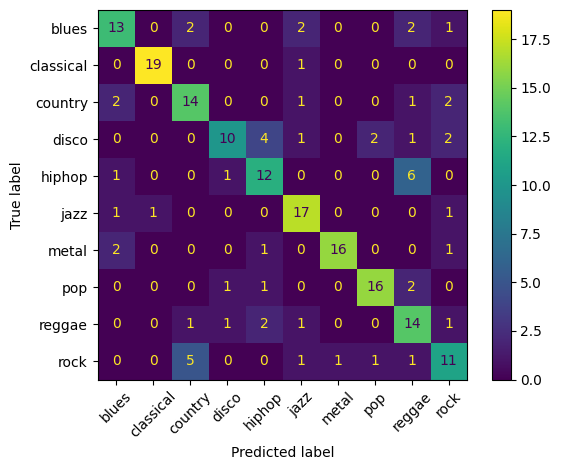

0.71

In [14]:
evaluate_model(skt.linear_model.LogisticRegression(max_iter=5000), X_train_scaled, y_train, X_test_scaled, y_test, le)

### 6.3 Support Vector Machine (RBF kernel)

`SVC` with the default RBF kernel can capture non-linear boundaries and usually performs
very well on standardized, medium-sized tabular datasets like this one.


Accuracy: 0.735
              precision    recall  f1-score   support

       blues       0.82      0.70      0.76        20
   classical       0.95      1.00      0.98        20
     country       0.83      0.75      0.79        20
       disco       0.59      0.50      0.54        20
      hiphop       0.71      0.75      0.73        20
        jazz       0.71      0.85      0.77        20
       metal       0.80      0.80      0.80        20
         pop       0.78      0.70      0.74        20
      reggae       0.61      0.70      0.65        20
        rock       0.57      0.60      0.59        20

    accuracy                           0.73       200
   macro avg       0.74      0.74      0.73       200
weighted avg       0.74      0.73      0.73       200



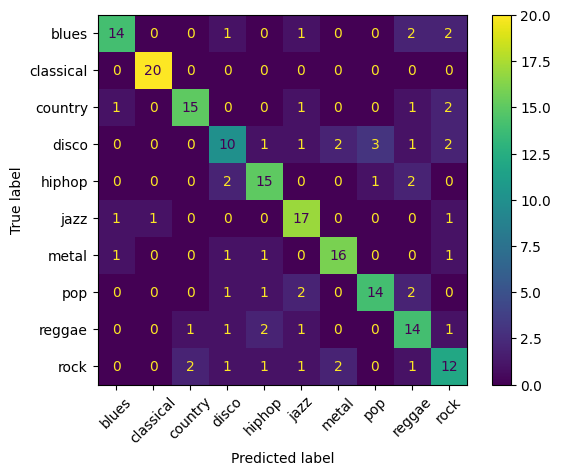

0.735

In [15]:
evaluate_model(skt.svm.SVC(), X_train_scaled, y_train, X_test_scaled, y_test, le)

### 6.4 Decision Tree

A single tree is highly interpretable but tends to over-fit and generalises worse than
ensembles — useful here mainly as a reference point.


Accuracy: 0.48
              precision    recall  f1-score   support

       blues       0.53      0.45      0.49        20
   classical       0.75      0.75      0.75        20
     country       0.46      0.30      0.36        20
       disco       0.25      0.25      0.25        20
      hiphop       0.46      0.55      0.50        20
        jazz       0.39      0.55      0.46        20
       metal       0.83      0.75      0.79        20
         pop       0.61      0.55      0.58        20
      reggae       0.29      0.40      0.33        20
        rock       0.36      0.25      0.29        20

    accuracy                           0.48       200
   macro avg       0.49      0.48      0.48       200
weighted avg       0.49      0.48      0.48       200



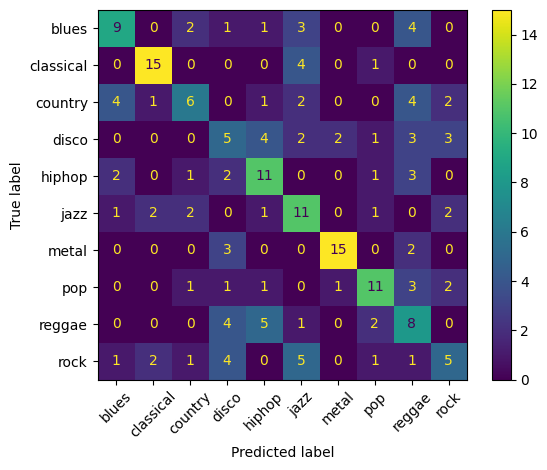

0.48

In [16]:
evaluate_model(skt.tree.DecisionTreeClassifier(), X_train_scaled, y_train, X_test_scaled, y_test, le)

### 6.5 Random Forest

An ensemble of many decorrelated trees. It typically beats a single tree by a wide margin
and is a robust go-to for tabular data.


Accuracy: 0.68
              precision    recall  f1-score   support

       blues       0.74      0.70      0.72        20
   classical       0.82      0.90      0.86        20
     country       0.80      0.80      0.80        20
       disco       0.58      0.35      0.44        20
      hiphop       0.54      0.70      0.61        20
        jazz       0.64      0.80      0.71        20
       metal       0.76      0.80      0.78        20
         pop       0.73      0.80      0.76        20
      reggae       0.56      0.50      0.53        20
        rock       0.60      0.45      0.51        20

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.67       200
weighted avg       0.68      0.68      0.67       200



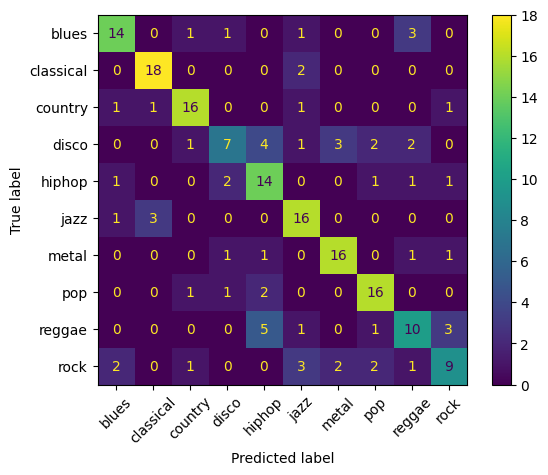

0.68

In [17]:
evaluate_model(skt.ensemble.RandomForestClassifier(), X_train_scaled, y_train, X_test_scaled, y_test, le)

## 7. Going further

So far we trained models one at a time on the 30-second features. Here we (a) compare all
models side by side, (b) exploit the much larger 3-second table, (c) tune the best model,
and (d) train a small neural network with PyTorch.

### 7.1 Side-by-side model comparison

We train every model in a loop, record test accuracy, and plot the results. We add a
**k-Nearest-Neighbours** classifier to the line-up for variety.


SVM (RBF)              0.735
Logistic Regression    0.710
Random Forest          0.685
KNN (k=5)              0.670
Decision Tree          0.505
dtype: float64


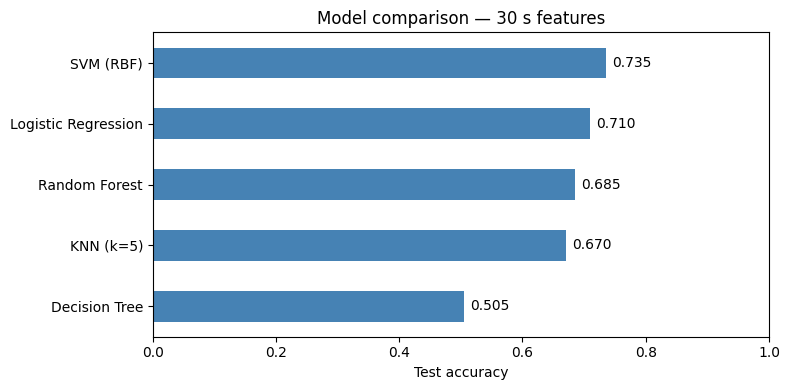

In [18]:
models = {
    "Logistic Regression": skt.linear_model.LogisticRegression(max_iter=5000),
    "SVM (RBF)":           skt.svm.SVC(),
    "Decision Tree":       skt.tree.DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       skt.ensemble.RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN (k=5)":           skt.neighbors.KNeighborsClassifier(n_neighbors=5),
}

scores = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    scores[name] = skt.metrics.accuracy_score(y_test, model.predict(X_test_scaled))

scores = pd.Series(scores).sort_values()
print(scores.sort_values(ascending=False).round(4))

ax = scores.plot.barh(figsize=(8, 4), color="steelblue")
ax.set_xlabel("Test accuracy")
ax.set_title("Model comparison — 30 s features")
ax.set_xlim(0, 1)
for i, v in enumerate(scores):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


### 7.2 Using the 3-second segments (≈10× more data)

More training data usually helps. The 3-second table has 9 990 rows instead of 1 000.
We repeat the same pipeline on it and evaluate a Random Forest.

> ⚠️ **Caveat — data leakage.** The ten 3-second segments of a song are *not*
> independent: a naive random split can place segments of the *same* track in both the
> train and test sets, inflating accuracy. The number below is therefore an optimistic
> upper bound. A rigorous evaluation would split by **track / filename** (e.g. with
> `GroupShuffleSplit`) so all segments of a song stay on the same side of the split.


Accuracy: 0.8634
              precision    recall  f1-score   support

       blues       0.82      0.83      0.83       200
   classical       0.91      0.96      0.93       199
     country       0.78      0.80      0.79       199
       disco       0.83      0.84      0.84       200
      hiphop       0.92      0.88      0.90       200
        jazz       0.86      0.90      0.88       200
       metal       0.86      0.96      0.91       200
         pop       0.95      0.82      0.88       200
      reggae       0.82      0.88      0.85       200
        rock       0.90      0.75      0.82       200

    accuracy                           0.86      1998
   macro avg       0.87      0.86      0.86      1998
weighted avg       0.87      0.86      0.86      1998



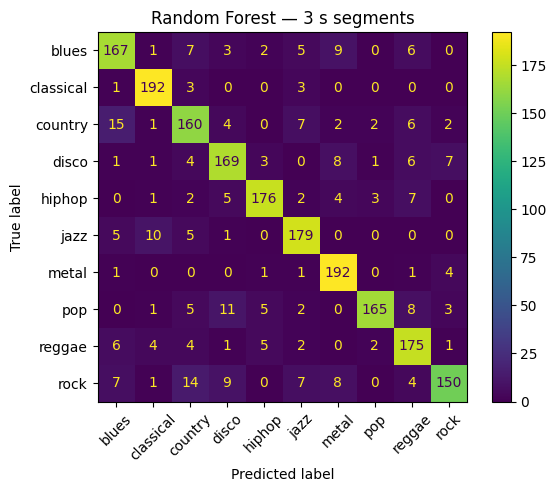

0.8633633633633634

In [19]:
# Labels share the same genre vocabulary, so we can reuse the fitted encoder.
y3 = le.transform(df_3sec["label"])
X3 = df_3sec.drop(["filename", "length", "label"], axis=1)

X3_train, X3_test, y3_train, y3_test = skt.model_selection.train_test_split(
    X3, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3
)

scaler3 = skt.preprocessing.StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

evaluate_model(
    skt.ensemble.RandomForestClassifier(random_state=RANDOM_STATE),
    X3_train_scaled, y3_train, X3_test_scaled, y3_test, le,
    title="Random Forest — 3 s segments",
)


### 7.3 Hyper-parameter tuning the Random Forest

`GridSearchCV` performs an exhaustive search over a small grid of hyper-parameters using
cross-validation on the training set, then reports the best configuration. We tune the
Random Forest on the 30-second features.


In [20]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
}

grid = skt.model_selection.GridSearchCV(
    skt.ensemble.RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
)
grid.fit(X_train_scaled, y_train)

print("Best CV accuracy:", round(grid.best_score_, 4))
print("Best params     :", grid.best_params_)

best_rf = grid.best_estimator_
test_acc = skt.metrics.accuracy_score(y_test, best_rf.predict(X_test_scaled))
print("Tuned test acc  :", round(test_acc, 4))


Best CV accuracy: 0.705
Best params     : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned test acc  : 0.69


### 7.4 A small neural network in PyTorch

Finally we put the imported `torch` to use with a compact **multi-layer perceptron (MLP)**
on the standardized 30-second features. Architecture: `input → 256 → 128 → 10` with ReLU
activations and dropout for regularisation, trained with the Adam optimiser and
cross-entropy loss.

For audio specifically, the natural next step is a **convolutional network operating on
the spectrogram/MFCC *images*** (using the helpers from section 3 plus `torchaudio`),
which can learn features end-to-end instead of relying on the pre-computed CSV columns.


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)

# Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

n_features = X_train_t.shape[1]
n_classes = len(le.classes_)

mlp = nn.Sequential(
    nn.Linear(n_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, n_classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 300
for epoch in range(EPOCHS):
    mlp.train()
    optimizer.zero_grad()
    logits = mlp(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        mlp.eval()
        with torch.no_grad():
            test_pred = mlp(X_test_t).argmax(dim=1)
            acc = (test_pred == y_test_t).float().mean().item()
        print(f"epoch {epoch + 1:3d} | loss {loss.item():.4f} | test acc {acc:.4f}")


Training on: cpu
epoch  50 | loss 0.8529 | test acc 0.6950
epoch 100 | loss 0.4465 | test acc 0.7250
epoch 150 | loss 0.2674 | test acc 0.7350
epoch 200 | loss 0.1637 | test acc 0.7200
epoch 250 | loss 0.1168 | test acc 0.7200
epoch 300 | loss 0.0736 | test acc 0.7500


## 8. Conclusion & next steps

**What we did.** We loaded the GTZAN dataset, explored how audio is represented as
spectrograms and MFCCs, and trained a range of models on the pre-computed feature tables.

**Takeaways.**
- On the 30-second features, kernel **SVM** and **Random Forest** are the strongest
  classical models; a single Decision Tree lags behind.
- The **3-second segments** give far more data and higher raw accuracy, but beware the
  **leakage** caveat — split by track for an honest estimate.
- The **MLP** is competitive but, on this many features and few samples, classical models
  remain hard to beat.

**Where to go next.**
- Split 3 s segments by track (`GroupShuffleSplit`) for leak-free evaluation.
- Build a **CNN on spectrogram/MFCC images** (raw `.wav` → `torchaudio` transforms) to
  learn features end-to-end.
- Add cross-validated confidence intervals and a final held-out test set.
- Try gradient-boosted trees (XGBoost / LightGBM) and audio-specific augmentation.
